MSE: 45536.379786785335
Sign accuracy: 0.85
White winning recall: 0.7
Black winning recall: 1.0
Draw recall: nan
Centipawn ±200 accuracy: 0.8
R2: 0.03185172362196753
R2 adjusted: 1.6569577589708078
Spearman rank correlation: 0.625563909774436


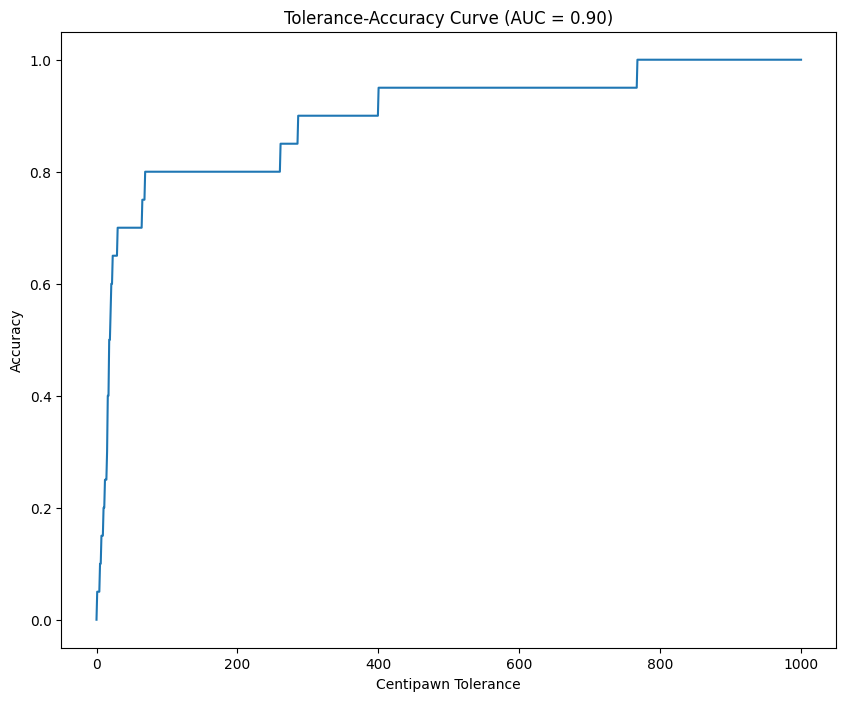

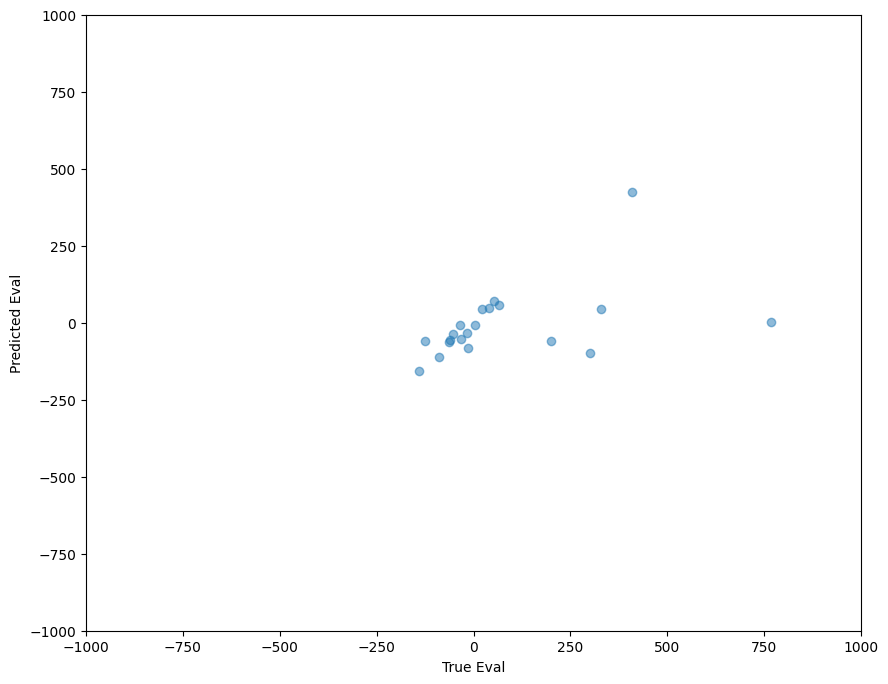

In [11]:
from sklearn.ensemble import GradientBoostingRegressor
from chess_eval import *
import pandas as pd

PIECE_VALUES = {
    chess.PAWN: 1.0,
    chess.KNIGHT: 3.0,
    chess.BISHOP: 3.0,
    chess.ROOK: 5.0,
    chess.QUEEN: 9.0,
    chess.KING: 0.0
}

CENTRAL_SQUARES = {chess.E4, chess.D4, chess.E5, chess.D5}

def is_passed_pawn(board, square, color):
    file = chess.square_file(square)
    rank = chess.square_rank(square)
    if color == chess.WHITE:
        # any black pawn on same or adjacent file ahead (higher ranks)?
        for r in range(rank + 1, 8):
            for f in (file - 1, file, file + 1):
                if 0 <= f < 8:
                    sq = chess.square(f, r)
                    piece = board.piece_type_at(sq)
                    if piece == chess.PAWN and not board.color_at(sq):
                        return False
        return True
    else:
        # black pawn: look for white pawns ahead (lower ranks)
        for r in range(rank - 1, -1, -1):
            for f in (file - 1, file, file + 1):
                if 0 <= f < 8:
                    sq = chess.square(f, r)
                    piece = board.piece_type_at(sq)
                    if piece == chess.PAWN and board.color_at(sq):
                        return False
        return True

def pawn_stats(board, color):
    pawns = [sq for sq, piece in board.piece_map().items() if piece.piece_type == chess.PAWN and piece.color == color]
    files = {}
    doubled = 0
    isolated = 0
    passed = 0
    for sq in pawns:
        f = chess.square_file(sq)
        files.setdefault(f, 0)
        files[f] += 1
    doubled = sum(count - 1 for count in files.values() if count > 1)
    # isolated: file has pawns ==1 and no pawns on adjacent files
    for f, count in files.items():
        if count == 1 and files.get(f - 1, 0) == 0 and files.get(f + 1, 0) == 0:
            isolated += 1
    for sq in pawns:
        if is_passed_pawn(board, sq, color):
            passed += 1
    pawn_islands = 0
    sorted_files = sorted(files.keys())
    if sorted_files:
        prev = sorted_files[0] - 2
        for f in sorted_files:
            if f != prev + 1:
                pawn_islands += 1
            prev = f
    return {"doubled": doubled, "isolated": isolated, "passed": passed, "islands": pawn_islands}

def extract_features_from_fen(fen: str) -> dict:
    b = chess.Board(fen)
    features = {}
    # counts and material
    for color, prefix in ((chess.WHITE, "W_"), (chess.BLACK, "B_")):
        mat = 0.0
        for ptype in (chess.PAWN, chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN, chess.KING):
            cnt = len([1 for sq, pc in b.piece_map().items() if pc.piece_type == ptype and pc.color == color])
            features[f"{prefix}count_{ptype}"] = cnt
            mat += cnt * PIECE_VALUES[ptype]
        features[f"{prefix}material"] = mat
        # bishop pair
        features[f"{prefix}bishop_pair"] = int(features[f"{prefix}count_{chess.BISHOP}"] >= 2)
    # material diff and total
    features["mat_diff"] = features["W_material"] - features["B_material"]
    features["mat_total"] = features["W_material"] + features["B_material"]

    # mobility: legal moves for each side
    b_white = b.copy()
    b_white.turn = True
    features["mobility_white"] = len(list(b_white.legal_moves))
    b_black = b.copy()
    b_black.turn = False
    features["mobility_black"] = len(list(b_black.legal_moves))
    # mobility for side to move
    features["mobility_to_move"] = len(list(b.legal_moves))

    # king safety: attackers on king and in king zone
    wk_sq = b.king(chess.WHITE)
    bk_sq = b.king(chess.BLACK)
    features["W_king_attackers"] = 0 if wk_sq is None else len(b.attackers(chess.BLACK, wk_sq))
    features["B_king_attackers"] = 0 if bk_sq is None else len(b.attackers(chess.WHITE, bk_sq))
    # king zone attackers
    def king_zone_attackers(board, king_sq, attacker_color):
        if king_sq is None:
            return 0
        zone = [king_sq] + [n for n in chess.SQUARES if chess.square_distance(king_sq, n) == 1]
        return sum(len(board.attackers(attacker_color, sq)) for sq in zone)
    features["W_king_zone_attackers"] = king_zone_attackers(b, wk_sq, chess.BLACK)
    features["B_king_zone_attackers"] = king_zone_attackers(b, bk_sq, chess.WHITE)

    # pawn structure features
    pw = pawn_stats(b, chess.WHITE)
    pb = pawn_stats(b, chess.BLACK)
    for k, v in pw.items():
        features[f"W_pawn_{k}"] = v
    for k, v in pb.items():
        features[f"B_pawn_{k}"] = v

    # center control: attacks on central squares
    features["center_control_white"] = sum(1 for sq in CENTRAL_SQUARES if b.is_attacked_by(chess.WHITE, sq))
    features["center_control_black"] = sum(1 for sq in CENTRAL_SQUARES if b.is_attacked_by(chess.BLACK, sq))

    # central piece presence
    features["W_central_pieces"] = sum(1 for sq, pc in b.piece_map().items() if pc.color == chess.WHITE and sq in CENTRAL_SQUARES)
    features["B_central_pieces"] = sum(1 for sq, pc in b.piece_map().items() if pc.color == chess.BLACK and sq in CENTRAL_SQUARES)

    # castling rights and en-passant
    features["W_can_castle_kingside"] = int(b.has_kingside_castling_rights(chess.WHITE))
    features["W_can_castle_queenside"] = int(b.has_queenside_castling_rights(chess.WHITE))
    features["B_can_castle_kingside"] = int(b.has_kingside_castling_rights(chess.BLACK))
    features["B_can_castle_queenside"] = int(b.has_queenside_castling_rights(chess.BLACK))
    features["has_ep"] = int(b.ep_square is not None)
    features["in_check"] = int(b.is_check())

    # move counters / phase
    features["halfmove_clock"] = b.halfmove_clock
    features["fullmove_number"] = b.fullmove_number
    initial_total = sum(v * cnt for v, cnt in [
        (PIECE_VALUES[chess.PAWN], 16),
        (PIECE_VALUES[chess.KNIGHT], 4),
        (PIECE_VALUES[chess.BISHOP], 4),
        (PIECE_VALUES[chess.ROOK], 4),
        (PIECE_VALUES[chess.QUEEN], 2),
    ])
    features["phase"] = (features["mat_total"] / initial_total) if initial_total > 0 else 0.0

    # side to move
    features["side_to_move_white"] = int(b.turn)

    return features

dm = DataManager(
    filepath=DATASET_FILE,
    read_size=READ_SIZE,
    sample_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)

dm.X = pd.DataFrame([extract_features_from_fen(fen) for fen in dm.df[FEN]])
dm.train_test_split(dm.X.columns.to_list())

mm = ModelManager(GradientBoostingRegressor(), dm)
mm.fit()
mm.predict()

metrics = MetricsManager(mm=mm)
metrics.report()
metrics.plot_tol_acc()
metrics.plot_scatter()